In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sb 

In [2]:
df=pd.read_csv("datasets/maaza_from_dump.csv")

In [3]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,723246245027,"Maaza, Mango Juice",House Of Spices,NaN,united-states,NaN,NaN,NaN,unknown,4.0,unknown,"Water, pure mango pulp, sugar, citric acid, na...",12.8,56.0
1,755270000310,Jus De Litchi Maaza 1L Pay Bas,Maaza,jus-de-litchi,france,NaN,NaN,NaN,c,NaN,NaN,NaN,NaN,NaN
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,NaN,france,bouteille,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
3,755270000365,Jus De Mangue 1L,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,NaN,NaN,NaN,e,4.0,NaN,"eau, purée de mangue (21%), sucre, acidulant: ...",NaN,NaN
4,755270000518,Maaza Lychee,Maaza,"beverages, sweetened-beverages",france,NaN,NaN,NaN,e,4.0,NaN,"eau, purée de litchi (18%), sucre, stabilisant...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,6611113,Maaza mango 350ml,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
120,6614892,Maaza Mango GST,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
121,6605358,Maaza tropical,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
122,6611558,Maaza Tropical,Maaza,NaN,netherlands,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [4]:
df.code[df.duplicated()]

Series([], Name: code, dtype: int64)

In [5]:
df.isnull().sum()

code                             0
product_name                     2
brands                           9
categories_tags                 71
countries_tags                   4
packaging_tags                 108
stores                         121
purchase_places                118
nutriscore_grade                 0
nova_group                      81
ecoscore_grade                 112
ingredients_text                78
nutriments.sugars_100g         106
nutriments.energy-kcal_100g    103
dtype: int64

In [6]:
df.dtypes

code                             int64
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [7]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

In [8]:
df['product_name']=df['product_name'].fillna('unknown')
df['brands']=df['brands'].fillna('unknown')
df['categories_tags']=df['categories_tags'].fillna('unknown')
df['countries_tags']=df['countries_tags'].fillna('unknown')
df['packaging_tags']=df['packaging_tags'].fillna('unknown')
df['stores']=df['stores'].fillna('unknown')
df['purchase_places']=df['purchase_places'].fillna('unknown')
df['ecoscore_grade']=df['ecoscore_grade'].fillna('unknown')
df['ingredients_text']=df['ingredients_text'].fillna('unknown')

In [9]:
df.countries_tags.unique()

array(['united-states', 'france', 'france, germany', 'netherlands',
       'france, senegal', 'india', 'belgium', 'unknown', 'spain',
       'india, united-states', 'united-kingdom', 'denmark'], dtype=object)

In [10]:
df.categories_tags.unique()

array(['unknown', 'jus-de-litchi',
       'plant-based-foods-and-beverages, beverages, plant-based-beverages, fruit-based-beverages, mango-based-beverages',
       'beverages, sweetened-beverages',
       'plant-based-foods-and-beverages, beverages, plant-based-beverages, fruit-based-beverages, unsweetened-beverages, sweetened-beverages',
       'plant-based-foods-and-beverages, beverages, plant-based-beverages, fruit-based-beverages, sweetened-beverages',
       'beverages',
       'beverages, sweetened-beverages, boisson-non-gazeuse-aux-jus-de-fruits',
       'beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, fruit-based-beverages, juices-and-nectars, fruit-juices',
       'plant-based-foods-and-beverages, beverages, plant-based-beverages, fruit-based-beverages',
       'beverages-and-beverages-preparations, beverages, sweetened-beverages',
       'beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, 

# Data cleaning Observation 
* findes duplicates columns and null values in the data 
* Nan values are replace vith unknown in all column
* cheaking unique values of columns 

# countries tags

In [11]:
raw_countries= df.countries_tags.str.split(',')
raw_countries

0      [united-states]
1             [france]
2             [france]
3             [france]
4             [france]
            ...       
119      [netherlands]
120      [netherlands]
121      [netherlands]
122      [netherlands]
123      [netherlands]
Name: countries_tags, Length: 124, dtype: object

In [12]:
exploded=raw_countries.explode().str.strip()

exploded

0      united-states
1             france
2             france
3             france
4             france
           ...      
119      netherlands
120      netherlands
121      netherlands
122      netherlands
123      netherlands
Name: countries_tags, Length: 128, dtype: object

In [13]:
exploded.value_counts()

countries_tags
france            42
netherlands       42
india             19
united-states     13
unknown            4
germany            2
united-kingdom     2
senegal            1
belgium            1
spain              1
denmark            1
Name: count, dtype: int64

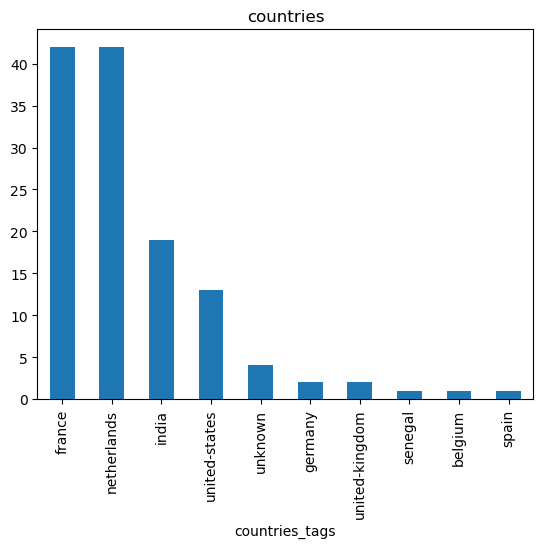

In [14]:
country_graph = exploded.value_counts().head(10).plot(kind='bar' ,title='countries')
plt.show()


# categories tags

In [15]:
raw_categories=df.categories_tags.str.split(',')
raw_categories

0                                              [unknown]
1                                        [jus-de-litchi]
2                                              [unknown]
3      [plant-based-foods-and-beverages,  beverages, ...
4                      [beverages,  sweetened-beverages]
                             ...                        
119                                            [unknown]
120                                            [unknown]
121                                            [unknown]
122                                            [unknown]
123                                            [unknown]
Name: categories_tags, Length: 124, dtype: object

In [16]:
exploded_categories=raw_categories.explode().str.strip()
exploded_categories

0                              unknown
1                        jus-de-litchi
2                              unknown
3      plant-based-foods-and-beverages
3                            beverages
                    ...               
119                            unknown
120                            unknown
121                            unknown
122                            unknown
123                            unknown
Name: categories_tags, Length: 317, dtype: object

In [17]:
exploded_categories.value_counts()

categories_tags
unknown                                  71
beverages                                49
sweetened-beverages                      30
beverages-and-beverages-preparations     28
plant-based-foods-and-beverages          27
plant-based-beverages                    26
fruit-based-beverages                    23
juices-and-nectars                       14
fruit-juices                             11
unsweetened-beverages                     4
fruit-nectars                             2
sweet-snacks                              1
snacks                                    1
confectioneries                           1
coconut-waters                            1
hot-beverages                             1
teas                                      1
desserts                                  1
mango-juice                               1
guava-juice-from-concentrate              1
aloe-vera-drinks                          1
Ready to serve fruit drink                1
Cooldrank       

In [18]:
exploded_categories[exploded_categories != 'unknown'].value_counts()

categories_tags
beverages                                49
sweetened-beverages                      30
beverages-and-beverages-preparations     28
plant-based-foods-and-beverages          27
plant-based-beverages                    26
fruit-based-beverages                    23
juices-and-nectars                       14
fruit-juices                             11
unsweetened-beverages                     4
fruit-nectars                             2
jus-de-litchi                             1
hot-beverages                             1
coconut-waters                            1
sweet-snacks                              1
confectioneries                           1
snacks                                    1
teas                                      1
Ready to serve fruit drink                1
mango-juice                               1
guava-juice-from-concentrate              1
aloe-vera-drinks                          1
Cooldrank                                 1
desserts        

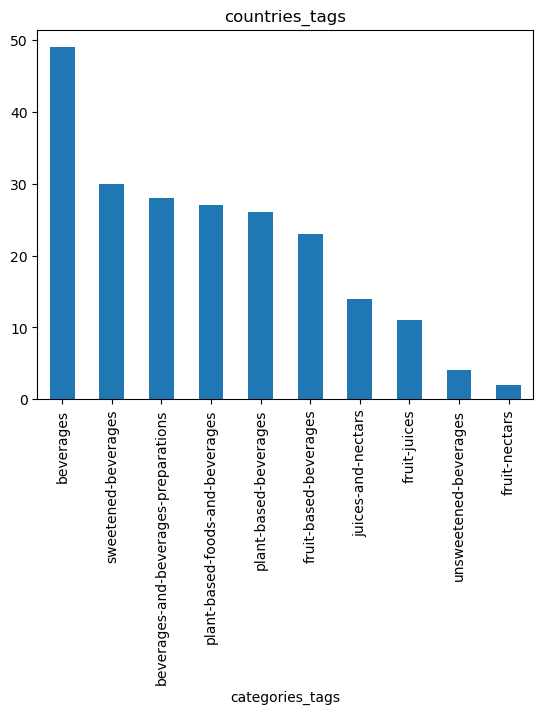

In [19]:
exploded_categories[exploded_categories != 'unknown'].value_counts().head(10).plot(kind='bar' ,title='countries_tags')
plt.show()


In [20]:
exploded_categories.value_counts()

categories_tags
unknown                                  71
beverages                                49
sweetened-beverages                      30
beverages-and-beverages-preparations     28
plant-based-foods-and-beverages          27
plant-based-beverages                    26
fruit-based-beverages                    23
juices-and-nectars                       14
fruit-juices                             11
unsweetened-beverages                     4
fruit-nectars                             2
sweet-snacks                              1
snacks                                    1
confectioneries                           1
coconut-waters                            1
hot-beverages                             1
teas                                      1
desserts                                  1
mango-juice                               1
guava-juice-from-concentrate              1
aloe-vera-drinks                          1
Ready to serve fruit drink                1
Cooldrank       

# packaging tags

In [21]:
df.packaging_tags.unique()

array(['unknown', 'bouteille', 'plastic, bottle', 'bouteille-plastique',
       'canette-aluminium', 'brick, cardboard', 'brick',
       'tetra-pak, brick, cardboard', 'cardboard, paperboard', 'bottle',
       'plastic-bottle', 'multilayer-composite, tetra-pak', 'can'],
      dtype=object)

In [22]:
raw_packaging=df.packaging_tags.str.split(',')
raw_packaging

0        [unknown]
1        [unknown]
2      [bouteille]
3        [unknown]
4        [unknown]
          ...     
119      [unknown]
120      [unknown]
121      [unknown]
122      [unknown]
123      [unknown]
Name: packaging_tags, Length: 124, dtype: object

In [23]:
exploded_packaging=raw_packaging.explode().str.strip()
exploded_packaging

0        unknown
1        unknown
2      bouteille
3        unknown
4        unknown
         ...    
119      unknown
120      unknown
121      unknown
122      unknown
123      unknown
Name: packaging_tags, Length: 134, dtype: object

In [24]:
exploded_packaging.value_counts()

packaging_tags
unknown                 108
brick                     5
cardboard                 5
bottle                    4
plastic                   3
tetra-pak                 2
bouteille                 1
bouteille-plastique       1
canette-aluminium         1
paperboard                1
plastic-bottle            1
multilayer-composite      1
can                       1
Name: count, dtype: int64

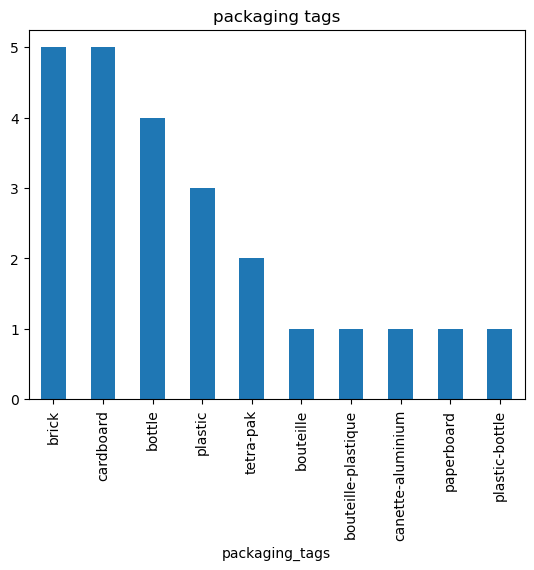

In [25]:
exploded_packaging[exploded_packaging != 'unknown'].value_counts().head(10).plot(kind='bar' ,title='packaging tags')
plt.show()


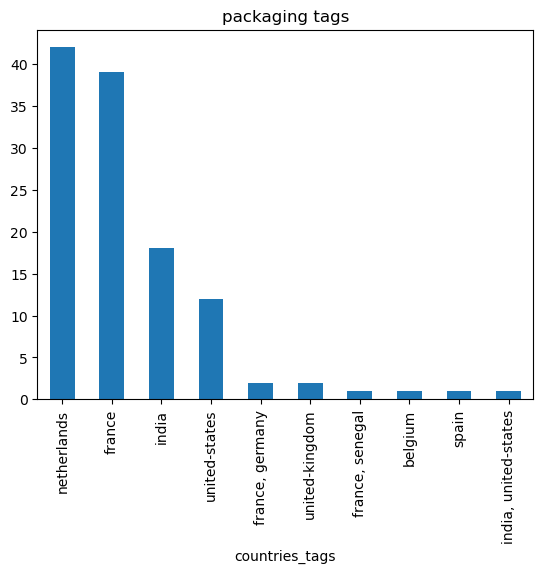

In [26]:
df.countries_tags[df.countries_tags != 'unknown'].value_counts().head(10).plot(kind='bar' ,title='packaging tags')
plt.show()

In [27]:
stores=df.stores.value_counts().drop("unknown")
stores

stores
Action                                          1
AZ sasu 45 rue Heurtault 93300 Aubervilliers    1
Auchan                                          1
Name: count, dtype: int64

In [28]:
df.packaging_tags.unique()

array(['unknown', 'bouteille', 'plastic, bottle', 'bouteille-plastique',
       'canette-aluminium', 'brick, cardboard', 'brick',
       'tetra-pak, brick, cardboard', 'cardboard, paperboard', 'bottle',
       'plastic-bottle', 'multilayer-composite, tetra-pak', 'can'],
      dtype=object)

In [29]:
raw_packaging = df.packaging_tags.str.split(',')
raw_packaging

0        [unknown]
1        [unknown]
2      [bouteille]
3        [unknown]
4        [unknown]
          ...     
119      [unknown]
120      [unknown]
121      [unknown]
122      [unknown]
123      [unknown]
Name: packaging_tags, Length: 124, dtype: object

In [30]:
exploded_packaging = raw_packaging.explode()
exploded_packaging

0        unknown
1        unknown
2      bouteille
3        unknown
4        unknown
         ...    
119      unknown
120      unknown
121      unknown
122      unknown
123      unknown
Name: packaging_tags, Length: 134, dtype: object

In [31]:
cleaned_packaging = exploded_packaging.str.strip()
cleaned_packaging

0        unknown
1        unknown
2      bouteille
3        unknown
4        unknown
         ...    
119      unknown
120      unknown
121      unknown
122      unknown
123      unknown
Name: packaging_tags, Length: 134, dtype: object

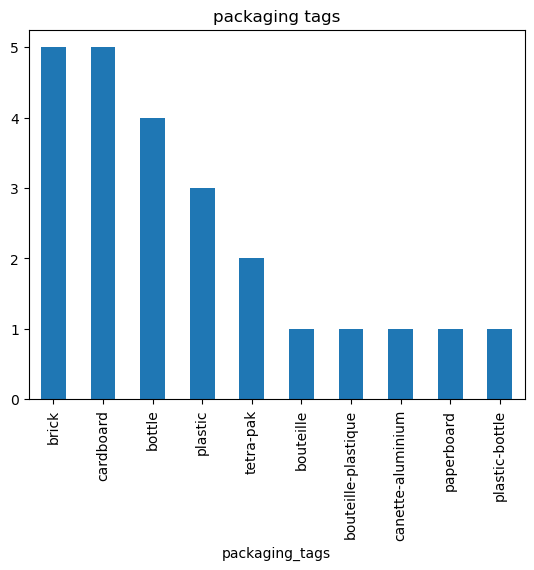

In [32]:
cleaned_packaging[exploded_packaging != 'unknown'].value_counts().head(10).plot(kind='bar' ,title='packaging tags')
plt.show()


In [33]:
cleaned_packaging = cleaned_packaging.str.replace('bouteille', 'bottle')

In [34]:
cleaned_packaging=cleaned_packaging.str.replace('bottle-plastique','bottle')

In [35]:
cleaned_packaging=cleaned_packaging.str.replace('plastic-bottle','bottle')

In [36]:
cleaned_packaging=cleaned_packaging.str.replace('canette-aluminium','can')

In [37]:
cleaned_packaging=cleaned_packaging.str.replace('tetra-pak','brick')

In [38]:
cleaned_packaging=cleaned_packaging.str.replace('paperboard','cardboard')

In [39]:
cleaned_packaging.value_counts().drop("unknown")

packaging_tags
bottle                  7
brick                   7
cardboard               6
plastic                 3
can                     2
multilayer-composite    1
Name: count, dtype: int64

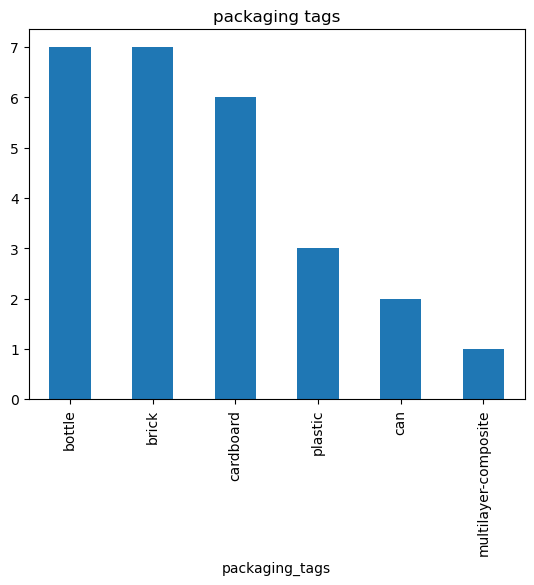

In [40]:
cleaned_packaging[exploded_packaging != 'unknown'].value_counts().head(10).plot(kind='bar' ,title='packaging tags')
plt.show()

In [41]:
packaging =df[df['packaging_tags'] !="unknown"]
packaging

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,unknown,france,bouteille,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
9,8718226321015,Tropical juice drink,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,"plastic, bottle",Action,France,e,4.0,unknown,"Eau, 25 % jus (purée de banane 10 % - pomme 10...",NaN,NaN
10,8718226321022,Maaza Guava,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,bouteille-plastique,unknown,unknown,e,4.0,unknown,"Eau, purée de goyave (18%), sucre, acidulant :...",NaN,NaN
14,8718226321534,Mango Juice drink,Maaza,"beverages, sweetened-beverages, boisson-non-ga...",france,canette-aluminium,AZ sasu 45 rue Heurtault 93300 Aubervilliers,"Aubervilliers,France",e,4.0,unknown,"eau, purée de mangues (18%), sucre, acidulant ...",NaN,NaN
19,8718226322036,Jus de Mangue,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,"plastic, bottle",unknown,"France,",e,4.0,unknown,"Eau, purée de mangue (18 %), sucre, acidifiant...",NaN,NaN
20,8718226322043,Jus de passion,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,"plastic, bottle",unknown,France,e,4.0,unknown,Eau jus de fruit de la passion à base de conce...,NaN,NaN
26,8718226323002,Lychee,Maaza,"plant-based-foods-and-beverages, beverages, pl...","france, germany","brick, cardboard",Auchan,"Noyelles-Godault,France",e,4.0,unknown,"Eau, purée de litchi (18%), sucre, acidulant: ...",NaN,NaN
28,8718226323026,Tropical,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,brick,unknown,unknown,e,4.0,unknown,"eau, 25% jus (purée de banane 10%, pomme 10%, ...",NaN,NaN
29,8718226323033,Guava Juice Drink,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,"brick, cardboard",unknown,unknown,e,4.0,unknown,"water, guava puree (18%), grape juice (3%), su...",NaN,NaN
31,8718226323057,papaya juice drink,Maaza,"beverages-and-beverages-preparations, plant-ba...",france,"brick, cardboard",unknown,unknown,e,4.0,unknown,"eau, purée de papaye (25%), sucre, acidulant :...",NaN,NaN


In [42]:
raw_purchase_places=df.purchase_places.str.split(',')
raw_purchase_places

0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
119    [unknown]
120    [unknown]
121    [unknown]
122    [unknown]
123    [unknown]
Name: purchase_places, Length: 124, dtype: object

# places

In [43]:
df.purchase_places.unique()

array(['unknown', 'France', 'Aubervilliers,France', 'France,',
       'Noyelles-Godault,France', 'Sénégal,France'], dtype=object)

In [44]:
raw_purches_places= df.purchase_places.str.split(",")
raw_purches_places


0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
119    [unknown]
120    [unknown]
121    [unknown]
122    [unknown]
123    [unknown]
Name: purchase_places, Length: 124, dtype: object

In [45]:
exploded_places=raw_purches_places.explode().str.strip()
exploded_places

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: purchase_places, Length: 128, dtype: object

In [46]:
drop_elements=exploded_places[exploded_places=="unknown"].index

In [47]:
exploded_places = exploded_places.drop(drop_elements)

In [48]:
drop_elements1=exploded_places[exploded_places==""].index

In [49]:
exploded_places = exploded_places.drop(drop_elements1)
exploded_places

9               France
14       Aubervilliers
14              France
20              France
26    Noyelles-Godault
26              France
33             Sénégal
33              France
Name: purchase_places, dtype: object

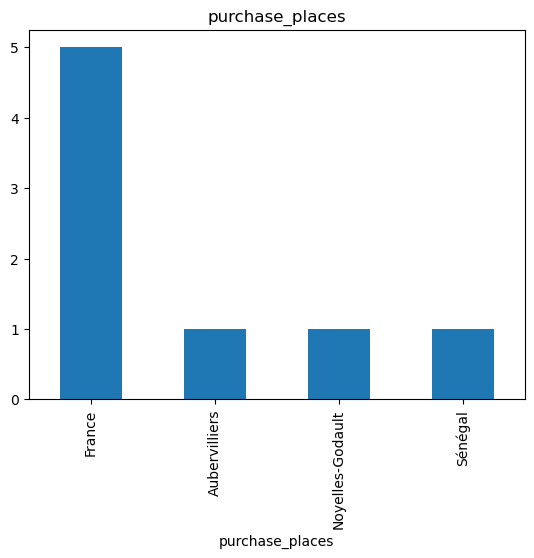

In [50]:
places_count = exploded_places.value_counts()

places_graph = places_count.plot(kind="bar",title="purchase_places")
plt.show()

# nutriscore grade

In [51]:
df.nutriscore_grade.unique()

array(['unknown', 'c', 'e', 'd', 'a'], dtype=object)

In [52]:
raw_grade=df.nutriscore_grade.str.split(",")
raw_grade

0      [unknown]
1            [c]
2      [unknown]
3            [e]
4            [e]
         ...    
119    [unknown]
120    [unknown]
121    [unknown]
122    [unknown]
123    [unknown]
Name: nutriscore_grade, Length: 124, dtype: object

In [53]:
exploded_grade= raw_grade.explode().str.strip()
exploded_grade

0      unknown
1            c
2      unknown
3            e
4            e
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: nutriscore_grade, Length: 124, dtype: object

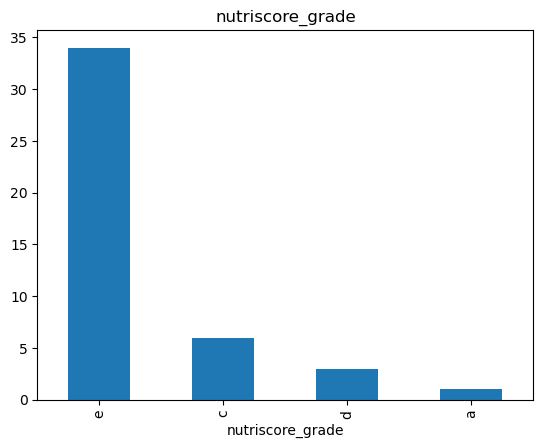

In [54]:
grade_graph = exploded_grade.value_counts().drop("unknown")
grade_graph.plot(kind="bar", title="nutriscore_grade")
plt.xticks(rotation=90)
plt.show()


In [55]:
df.nova_group.unique()

array([ 4., nan,  1.])

# escore grade

In [56]:
df.ecoscore_grade.unique()

array(['unknown', 'd', 'e', 'a'], dtype=object)

In [57]:
raw_escore_grade=df.ecoscore_grade.str.split(",")
raw_escore_grade

0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
119    [unknown]
120    [unknown]
121    [unknown]
122    [unknown]
123    [unknown]
Name: ecoscore_grade, Length: 124, dtype: object

In [58]:
exploded_escore_grade=raw_escore_grade.explode().str.strip()
exploded_escore_grade

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
119    unknown
120    unknown
121    unknown
122    unknown
123    unknown
Name: ecoscore_grade, Length: 124, dtype: object

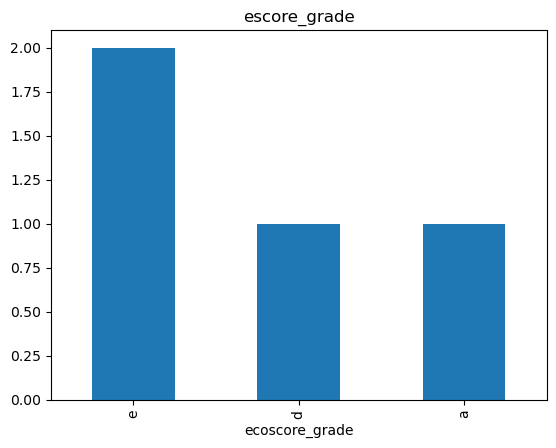

In [59]:
grade_graph=exploded_escore_grade.value_counts().drop("unknown")
grade_graph.plot(kind="bar",title="escore_grade")
plt.show()

In [60]:
exploded_escore_grade.value_counts()

ecoscore_grade
unknown    120
e            2
d            1
a            1
Name: count, dtype: int64

In [61]:
df.ingredients_text.unique()

array(['Water, pure mango pulp, sugar, citric acid, natural & artificial mango flavors, preservatives: sodium benzoate and potassium meta bi-sulphite. ascorbic acid, color fd & c yellow # 6.',
       'unknown',
       'eau, purée de mangue (21%), sucre, acidulant: acide citrique, aromes',
       'eau, purée de litchi (18%), sucre, stabilisant: xanthan, acidulant: acide citrique, arômes de litchi',
       'eau, purée de mangue (18%), sucre, acidulant: acide citrique, arômes de mangue,',
       'eau, purée de goyave (15%), sucre, acidulant: acide citrique, arômes, colorant: carmin.',
       'Eau, 25 % jus (purée de banane 10 % - pomme 10 % - ananas 2 % - jus de citron 2 %, pêche à base de concentré), sucre, acidifiant : acide citrique, arômes, colorant : B-carotène.',
       'Eau, purée de goyave (18%), sucre, acidulant : acide citrique, arômes, colorant : carmin.',
       'puree de goyave (ü 0 90), sucre, acjduldint• aci catmin.',
       'eau, purée de mangues (18%), sucre, acidulant : 

In [62]:
df.rename(columns={"nutriments.sugers_100g":"nutriments_sugers_100g"},inplace=True)

In [63]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,723246245027,"Maaza, Mango Juice",House Of Spices,unknown,united-states,unknown,unknown,unknown,unknown,4.0,unknown,"Water, pure mango pulp, sugar, citric acid, na...",12.8,56.0
1,755270000310,Jus De Litchi Maaza 1L Pay Bas,Maaza,jus-de-litchi,france,unknown,unknown,unknown,c,NaN,unknown,unknown,NaN,NaN
2,755270000358,Jus De Guana Bana (corossol) Maaza 1L Pay Bas,Kern's Nectar,unknown,france,bouteille,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
3,755270000365,Jus De Mangue 1L,Maaza,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de mangue (21%), sucre, acidulant: ...",NaN,NaN
4,755270000518,Maaza Lychee,Maaza,"beverages, sweetened-beverages",france,unknown,unknown,unknown,e,4.0,unknown,"eau, purée de litchi (18%), sucre, stabilisant...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,6611113,Maaza mango 350ml,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
120,6614892,Maaza Mango GST,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
121,6605358,Maaza tropical,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
122,6611558,Maaza Tropical,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


# all observation
* Analyze a unique values of each columns
* split multi valued entries for better analysis 
* apply the exploded function for expand list values into saprate rows 
* removed unknown values from colums for better visulization
* create saperate varibales for new modified data 
* kept the orignal dataset unchanged
* prepered transformed data for efective visulization 
* plot, visulize all columns top n values for better understand


# netherlands data

In [64]:
temp1 = df.countries_tags.str.split(',')
temp1.explode().value_counts()

countries_tags
france            42
netherlands       42
india             19
united-states     12
unknown            4
 germany           2
united-kingdom     2
 senegal           1
belgium            1
spain              1
 united-states     1
denmark            1
Name: count, dtype: int64

In [65]:
netherlands_data=df[df["countries_tags"].str.contains("netherlands")]
netherlands_data


,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
27,8718226323019,Banana Juice Drink,Maaza,"beverages-and-beverages-preparations, beverage...",netherlands,unknown,unknown,unknown,e,4.0,unknown,"water, banana puree (23%), lemon juice from co...",NaN,NaN
28,8718226323026,Tropical,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,brick,unknown,unknown,e,4.0,unknown,"eau, 25% jus (purée de banane 10%, pomme 10%, ...",NaN,NaN
29,8718226323033,Guava Juice Drink,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,"brick, cardboard",unknown,unknown,e,4.0,unknown,"water, guava puree (18%), grape juice (3%), su...",NaN,NaN
30,8718226323040,Mango Fruit Drink,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,unknown,unknown,unknown,e,4.0,unknown,"mangue 17%, sucre, stabilisant (pectine), acid...",NaN,NaN
32,8718226323064,"Passionsfruchtsaft, Passionsfrucht",Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,unknown,unknown,unknown,e,1.0,unknown,"water, passion fruit with a stabilizing sugar ...",NaN,NaN
46,8718226322227,Maaza Guava,Maaza,"plant-based-foods-and-beverages, beverages, pl...",netherlands,plastic-bottle,unknown,unknown,c,NaN,d,unknown,10.6,45.0
61,8718226321602,Tropical juice drink,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,can,unknown,unknown,d,NaN,e,unknown,11.8,48.0
65,8720157468479,Jus,Maaza,unknown,netherlands,unknown,unknown,unknown,unknown,4.0,unknown,"Water, guavesap uit concentraat 17%, suiker, s...",NaN,NaN
68,8720157400561,Mango Fruit Drink,Maaza,"plant-based-foods-and-beverages, beverages, pl...",netherlands,unknown,unknown,unknown,unknown,4.0,e,"Water, mangopuree 17%, suiker, stabilisator (p...",10.9,192.0
72,8720157468912,unknown,Maaza,"beverages-and-beverages-preparations, plant-ba...",netherlands,unknown,unknown,unknown,c,4.0,unknown,"Coconut water from concentrate (99,9%), aroma,...",4.0,19.0


In [66]:
netherlands_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 27 to 123
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code                         42 non-null     int64  
 1   product_name                 42 non-null     object 
 2   brands                       42 non-null     object 
 3   categories_tags              42 non-null     object 
 4   countries_tags               42 non-null     object 
 5   packaging_tags               42 non-null     object 
 6   stores                       42 non-null     object 
 7   purchase_places              42 non-null     object 
 8   nutriscore_grade             42 non-null     object 
 9   nova_group                   14 non-null     float64
 10  ecoscore_grade               42 non-null     object 
 11  ingredients_text             42 non-null     object 
 12  nutriments.sugars_100g       8 non-null      float64
 13  nutriments.energy-kcal_10

In [67]:
netherlands_data['product_name'].unique()

array(['Banana Juice Drink', 'Tropical', 'Guava Juice Drink',
       'Mango Fruit Drink', 'Passionsfruchtsaft, Passionsfrucht',
       'Maaza Guava', 'Tropical juice drink', 'Jus', 'unknown',
       'Guava juice', 'Mango fruit drînk',
       'Tropical con le Fruit drink Go on, you deser',
       'Tropical Fruit Drink', 'Guava Fruit Drink',
       'Aloe Vera Original Fruit Drink', 'Passion Fruit Drink',
       'mangosap', 'Mango fruity ice stick', 'Maaza Banana juice drink',
       'Maaza Kokoswater', 'Maaza Mango drink',
       'Maaza Passion fruit drink', 'Maaza Sparkling guava',
       'Maaza Sparkling mango', 'Maaza Tropical drink', 'Maaza banaan',
       'Maaza banaan 350ml', 'Maaza Banana', 'Maaza fruitijs mango',
       'Maaza guava 350ml', 'Maaza Guava GST', 'Maaza guave',
       'Maaza kokosnootwater', 'Maaza mango', 'Maaza Mango',
       'Maaza mango 350ml', 'Maaza Mango GST', 'Maaza tropical',
       'Maaza Tropical', 'Maaza tropical 350ml'], dtype=object)

In [68]:
netherlands_data['product_name'].value_counts()

product_name
Mango Fruit Drink                               2
Maaza Guava                                     2
Banana Juice Drink                              1
Maaza Guava GST                                 1
Maaza Sparkling mango                           1
Maaza Tropical drink                            1
Maaza banaan                                    1
Maaza banaan 350ml                              1
Maaza Banana                                    1
Maaza fruitijs mango                            1
Maaza guava 350ml                               1
Maaza kokosnootwater                            1
Maaza guave                                     1
Maaza Passion fruit drink                       1
Maaza mango                                     1
Maaza Mango                                     1
Maaza mango 350ml                               1
Maaza Mango GST                                 1
Maaza tropical                                  1
Maaza Tropical                       

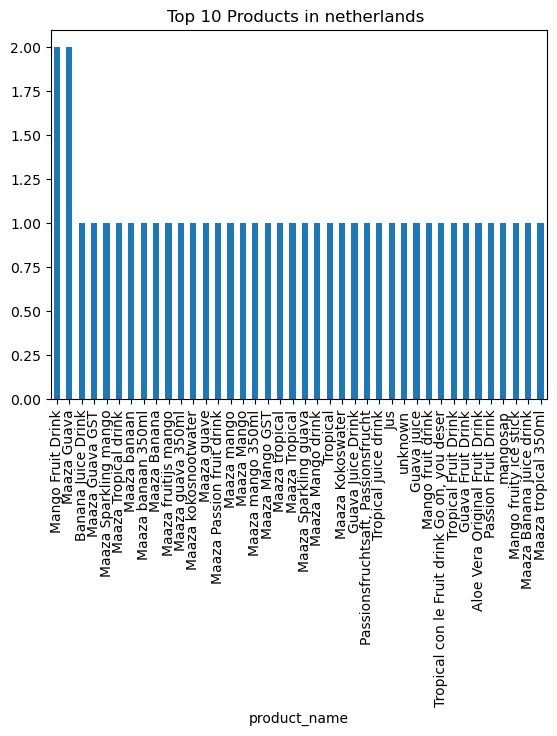

In [69]:
netherlands_data['product_name'].value_counts().plot(kind='bar')
plt.title('Top 10 Products in netherlands ')
plt.xticks(rotation=90)
plt.show()

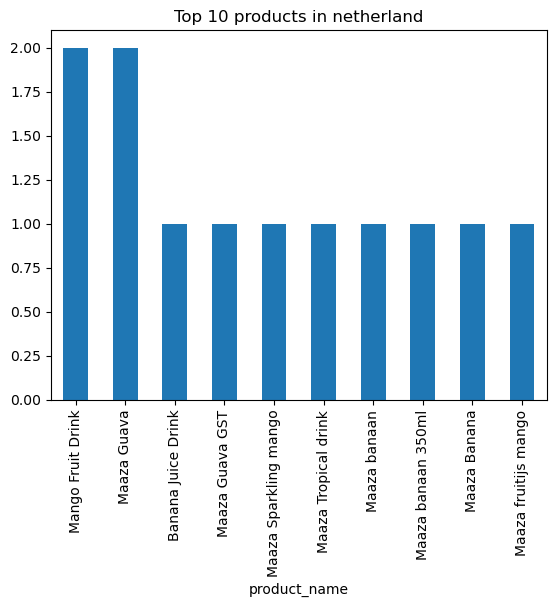

In [70]:
netherlands_data['product_name'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 products in netherland')
plt.show()

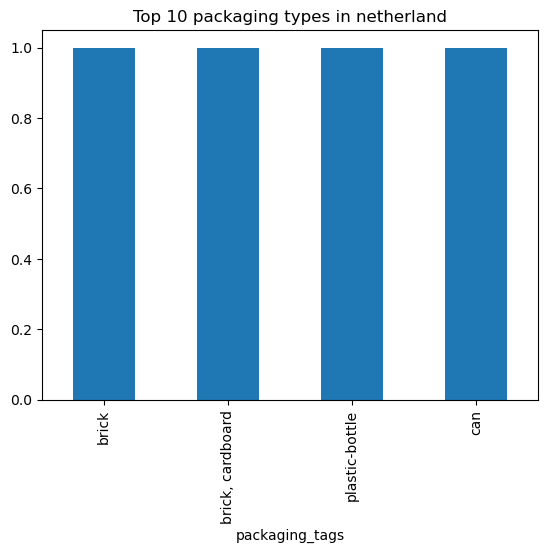

In [71]:
netherlands_data[netherlands_data != 'unknown']['packaging_tags'].value_counts().plot(kind='bar')
plt.title('Top 10 packaging types in netherland')
plt.show()

In [72]:
netherlands_data['packaging_tags'].value_counts()

packaging_tags
unknown             38
brick                1
brick, cardboard     1
plastic-bottle       1
can                  1
Name: count, dtype: int64

In [73]:
netherlands_data.packaging_tags.value_counts()

packaging_tags
unknown             38
brick                1
brick, cardboard     1
plastic-bottle       1
can                  1
Name: count, dtype: int64

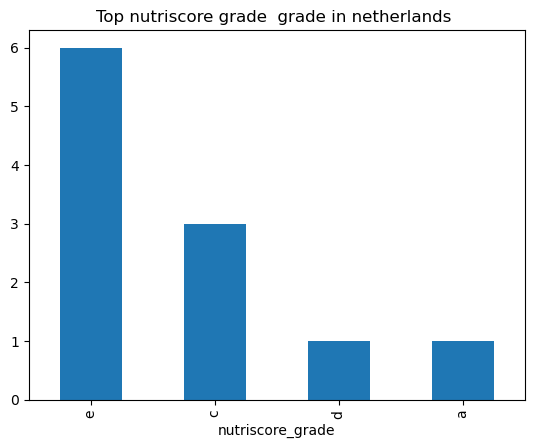

In [74]:
netherlands_data[netherlands_data != 'unknown']['nutriscore_grade'].value_counts().plot(kind='bar')
plt.title('Top nutriscore grade  grade in netherlands ')
plt.xticks(rotation=90)
plt.show()

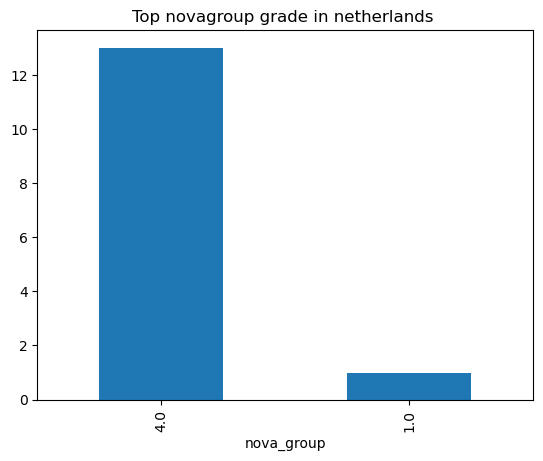

In [75]:
netherlands_data[netherlands_data != 'unknown']['nova_group'].value_counts().plot(kind='bar')
plt.title('Top novagroup grade in netherlands ')
plt.xticks(rotation=90)
plt.show()

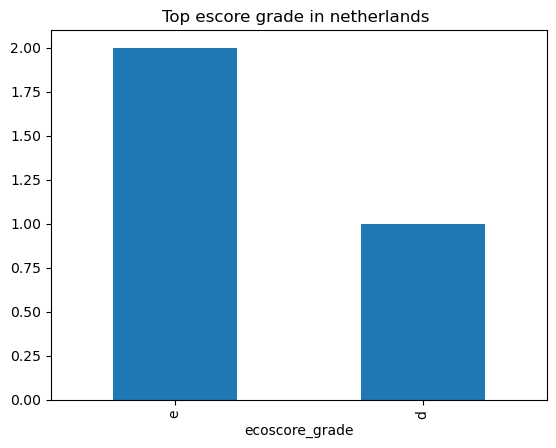

In [76]:
netherlands_data[netherlands_data != 'unknown']['ecoscore_grade'].value_counts().plot(kind='bar')
plt.title('Top escore grade in netherlands ')
plt.xticks(rotation=90)
plt.show()

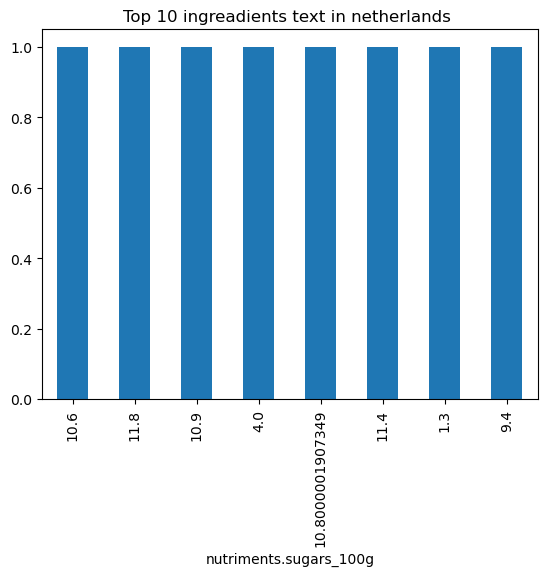

In [77]:
netherlands_data[netherlands_data != 'unknown']['nutriments.sugars_100g'].value_counts().plot(kind='bar')
plt.title('Top 10 ingreadients text in netherlands ')
plt.xticks(rotation=90)
plt.show()

# Netherlands Observation
* fetch the nethelands data from aactual data which is 42 rows.
* cheak the product names from data ,mango fruit drink and maaza guava having more contity as compare to other & other has same quantity
* plot the top 10 products from netherland data
* first cleaned and standarlized packaging tags where brick, cardbord, plastic bottel,and can are 1 and remaning are having unknown values
* nutriscore grade is grade E has a higest count that is 6 , and c :3 , D&A is 1 .
* analyze escore grade where E:2.00 & D:1.00 and remaning values are unknown 
* analyze nutriments.suger 100g but all are having same values thats why its nat have meaning
* in netherlands data stores and purches places is having unknown values 

# united states data

In [78]:
united_states = df[df["countries_tags"].str.contains("united-states",na=False)]
united_states

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,723246245027,"Maaza, Mango Juice",House Of Spices,unknown,united-states,unknown,unknown,unknown,unknown,4.0,unknown,"Water, pure mango pulp, sugar, citric acid, na...",12.8,56.0
60,867051000430,Aioli,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,219.0
62,867051000423,Original Chutney,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,31.2
64,3948764175091,maaza,Tetra Pak,"beverages, sweetened-beverages","india, united-states",unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
74,8720157468998,Guava,Maaza,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,10.9,46.0
79,860009776579,Lemon Aioli Magic Green Sauce,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,219.0
87,860009776500,Magic Lentil Dip,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,0.0,214.0
88,867051000492,Roasted Red Pepper Lentil Dip,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,0.0,214.0
89,867051000485,Turmeric Ginger Lentil Dip,Maazah Lentil Dip,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,0.0,214.0
91,860009776562,Chili Aioli,Maazah,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


In [79]:
united_states['product_name'].unique()

array(['Maaza, Mango Juice', 'Aioli', 'Original Chutney', 'maaza',
       'Guava', 'Lemon Aioli Magic Green Sauce', 'Magic Lentil Dip',
       'Roasted Red Pepper Lentil Dip', 'Turmeric Ginger Lentil Dip',
       'Chili Aioli'], dtype=object)

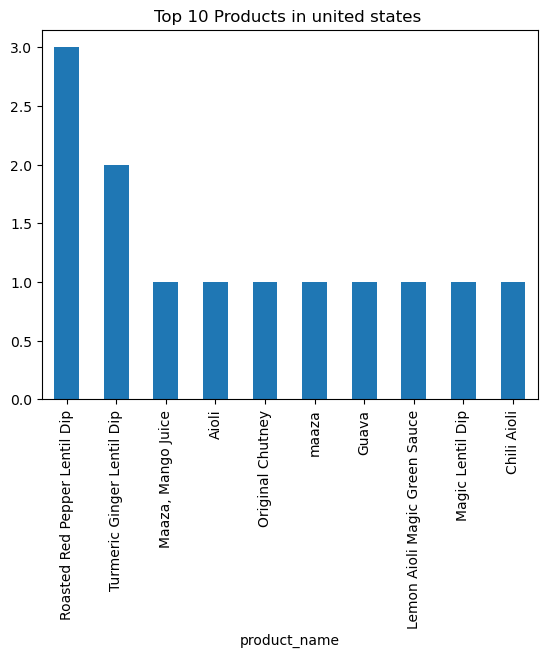

In [80]:
united_states['product_name'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Products in united states ')
plt.xticks(rotation=90)
plt.show()

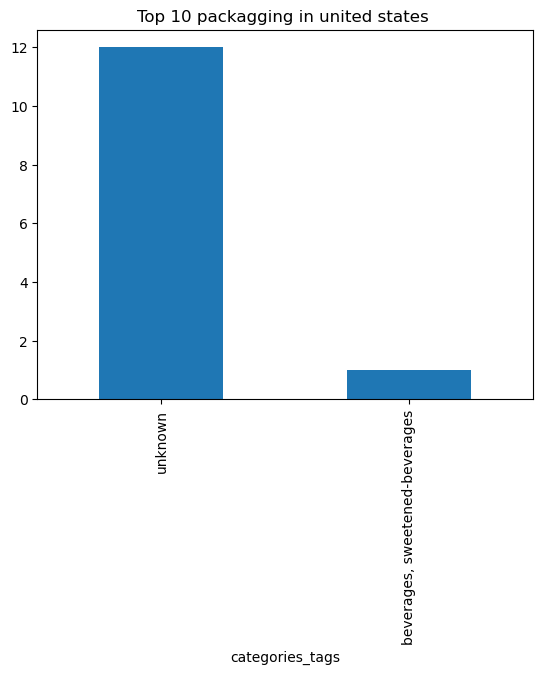

In [81]:
united_states['categories_tags'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 packagging in united states ')
plt.xticks(rotation=90)
plt.show()

In [82]:
united_states_brands= united_states['brands'].replace({'Maazah':'Maaza'})
united_states_brands

0       House Of Spices
60                Maaza
62                Maaza
64            Tetra Pak
74                Maaza
79                Maaza
87                Maaza
88                Maaza
89    Maazah Lentil Dip
91                Maaza
92                Maaza
96                Maaza
97                Maaza
Name: brands, dtype: object

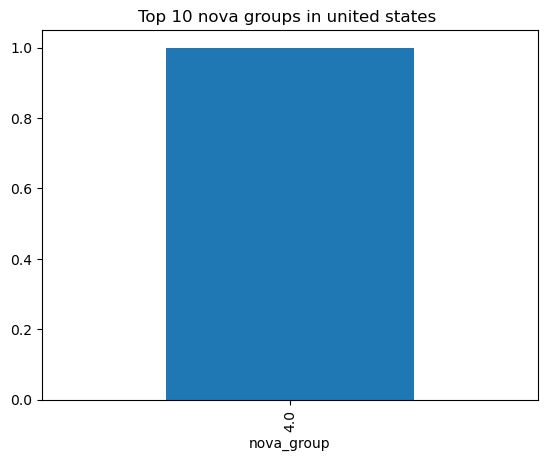

In [83]:
united_states['nova_group'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 nova groups in united states ')
plt.xticks(rotation=90)
plt.show()

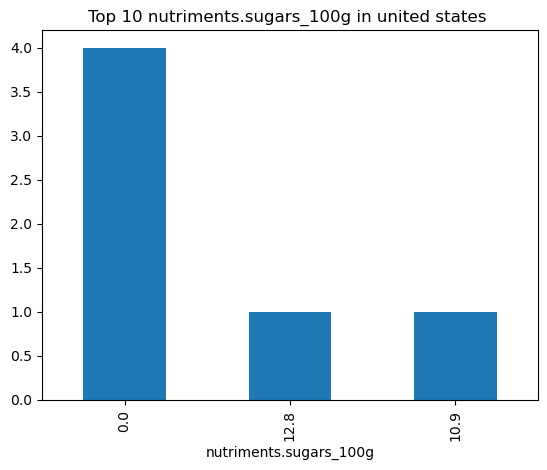

In [84]:
united_states['nutriments.sugars_100g'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 nutriments.sugars_100g in united states ')
plt.show()

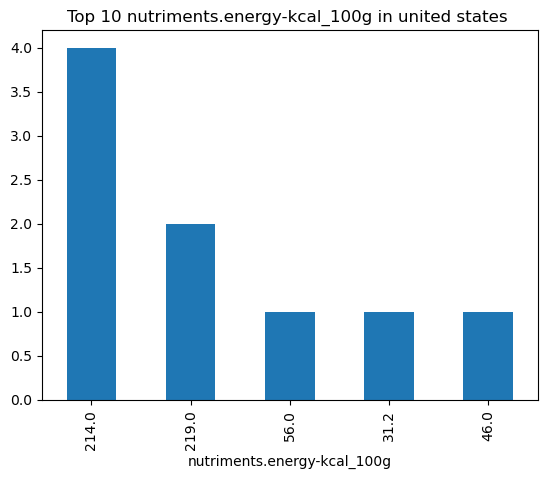

In [85]:
united_states['nutriments.energy-kcal_100g'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 nutriments.energy-kcal_100g in united states ')
plt.show()

# united state observation
* fetch and analyze the united state data , it having 13 rows of data 
* cheaks the unique product valus from united data which are 10.
* identify the top 10 product in united state , where rosted red paper lentil dip is 3.0 & Turmeric Ginger Lentil Dipis 2.0 and other all are 1.0 .
* nova group is having only one value that is 4.0 and other are unknown.
* in nutriments.sugars_100 0.0 g suger is most frequent value , 12.8g and 10.9g occures less values , overall most produts having zero suger 
* in nutriments.energy-kcal_100g 214, 219 kcal are the most values that is 4.0 and 2.0 and 56 , 31.2 , 46.0 occurless frequent values
* in the united state data packaging tags data , categouries tags, stores , purches places, nutriscore grade, escore grade are having unknown values 

# Comparision between Netherland and United states

In [86]:
country_count = pd.DataFrame({
    "Country": ["Netherlands", "United States"],
    "Products": [
        len(netherlands_data),
        len(united_states)
    ]
})

country_count

,Country,Products
0,Netherlands,42
1,United States,13


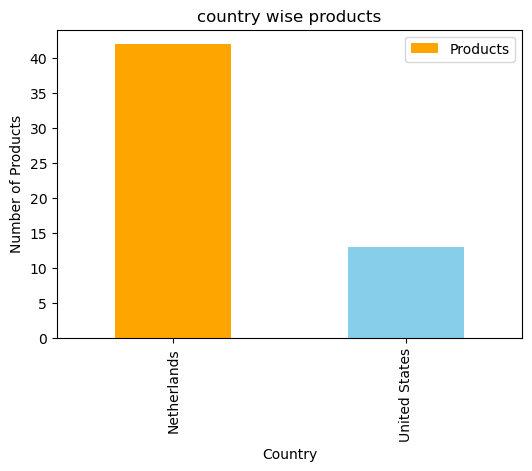

In [87]:
import matplotlib.pyplot as plt

country_count.plot(
    x="Country",
    y="Products",
    kind="bar",
    figsize=(6,4),
    color=["orange","skyblue"]
)
plt.title("country wise products")
plt.ylabel("Number of Products")
plt.show()

# Comparision between NL & US
* Product Data : Netherlands contains 42 rows with product information and United States contains only 13 rows, so the Netherlands has considerably more product records.
   In the Netherlands, Mango Fruit Drink and Maaza Guava have higher quantities than the other products . 
   In the United States, Roasted Red Pepper Lentil Dip appears 3 times, while Turmeric Ginger Lentil Dip appears 2 times.
* Unique Products : Netherlands contains a larger number of records and repeated products & United States 10 unique products among 13 records.

* Packaging Tags : Netherlands Packaging tags were cleaned and standardized. Brick, cardboard, plastic bottle, and can while other are unknown.
   United States Packaging tags contain all unknown values.

* Purchase Places : Netherlands and united states both Purchase-place information is mostly unknown.

* Stores : Netherlands & united states both Store information has unknown values.

* Nutriscore Grade : Netherlands Nutriscore information is E has a higest count that is 6 , and c :3 , D&A is 1 respectivly and US have all unknown values 

* nova group : Netherlands Nova Group information is having 4.0 is most values which is more than 12 , while us is only one 4.0 which is 1.0 .

* escore grade : Netherlands Ecoscore grades E = 2.00 and D = 1.00 and other values are unknown. United States contains unknown values.
   Therefore, netherlandsEcoscore information is more useful than in United States.

* Sugar — nutriments.sugars_100g : Netherlands Sugar values all are 1.0 , United States 0.0 g is the most sugar value, while 12.8 g and 10.9 g occur less frequently.
     Therefore, sugar content provides more useful variation in the U.S. data than in the Netherlands.


* Energy — nutriments.energy-kcal_100g : Netherlands Energy values do not show much useful , United States 214 kcal and 219 kcal are more values, while 56, 31.2, and 46 kcal less value     
   therefore, the U.S. dataset provides more variation in energy values.
 
     ## Overall Observation :

   * Netherlands has 42 records , while the U.S. has 13 records.
   * Netherlands has more product data; **Mango Fruit Drink and Maaza Guava** are more quantity , .U.S. data is dominated by Roasted Red Pepper Lentil Dip.
   * **Packaging, stores, purchase places, brands, and categories** have many unknown values in both.
   * Netherlands has better **Ecoscore** information, while U.S. has **Nova Group 4** identified.
   * **Sugar and energy values** show more variation in the U.S.
   * Overall, **Netherlands data is larger and more suitable for analysis**, while U.S. data is smaller and more incomplete.
   * some columns not analyze beacouse nan values 
